In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

ROOT = Path("Bird Speciees Dataset")  

paths = sorted(
    p for p in ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

if not paths:
    raise FileNotFoundError(f"No images found in {ROOT.resolve()}")

print(f"{len(paths)} images")

811 images


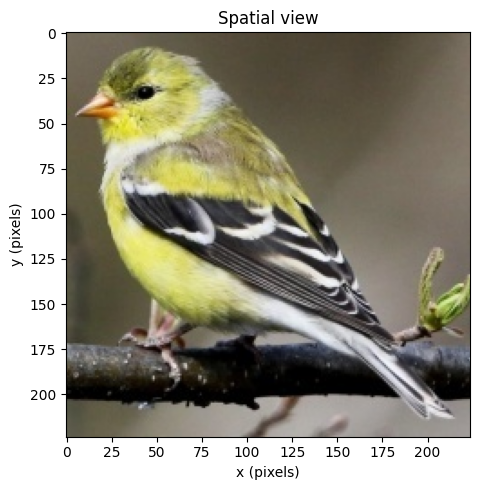

In [2]:
arr = np.asarray(Image.open(paths[0]).convert("RGB"))

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(arr)
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_title("Spatial view")
plt.tight_layout()
plt.show()

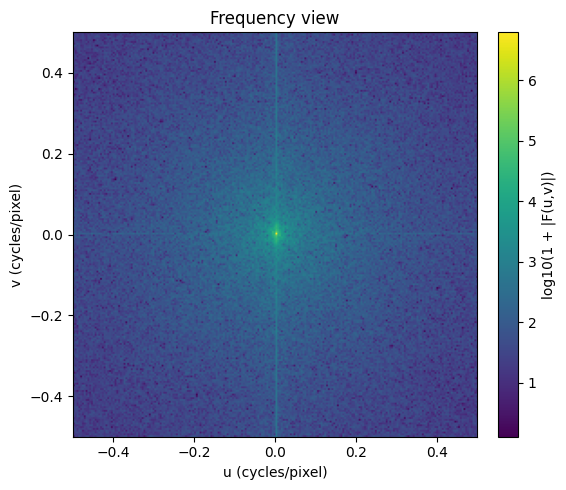

In [3]:
# Mean image across the dataset
mean_img = np.zeros((224, 224, 3), dtype=np.float64)
for p in paths:
    mean_img += np.asarray(Image.open(p).convert("RGB"), dtype=np.float64)
mean_img /= len(paths)
gray = mean_img.mean(axis=2)

# 2-D FFT
F = np.fft.fftshift(np.fft.fft2(gray))
mag = np.log10(1 + np.abs(F))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    mag,
    extent=[-0.5, 0.5, -0.5, 0.5],
    origin="lower",
    cmap="viridis",
)
ax.set_xlabel("u (cycles/pixel)")
ax.set_ylabel("v (cycles/pixel)")
ax.set_title("Frequency view")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("log10(1 + |F(u,v)|)")
plt.tight_layout()
plt.show()

In [4]:
import numpy as np
from pathlib import Path
from PIL import Image

def low_pass(gray, fc):
    F = np.fft.fftshift(np.fft.fft2(gray))
    fy = np.fft.fftshift(np.fft.fftfreq(gray.shape[0]))
    FX, FY = np.meshgrid(fy, fy)
    R = np.sqrt(FX**2 + FY**2)
    H = (R <= fc).astype(np.float64)
    return np.real(np.fft.ifft2(np.fft.ifftshift(F * H)))

def alpha_and_hf(gray, fc_max=0.5):
    F = np.fft.fftshift(np.fft.fft2(gray))
    power = np.abs(F) ** 2
    fy = np.fft.fftshift(np.fft.fftfreq(gray.shape[0]))
    FX, FY = np.meshgrid(fy, fy)
    R = np.sqrt(FX**2 + FY**2)
    bins = np.linspace(0, 0.5, 50)
    freqs = 0.5 * (bins[:-1] + bins[1:])
    idx = np.digitize(R.ravel(), bins)
    radial = np.array([
        power.ravel()[idx == i].mean()
        for i in range(1, len(bins))
    ])
    m = (freqs > 0.02) & (freqs < fc_max)
    alpha = -np.polyfit(np.log10(freqs[m]), np.log10(radial[m]), 1)[0]
    hf = power[R > 0.25].sum() / power[R > 0.02].sum()
    return alpha, hf

cutoffs = [0.5, 0.25, 0.125, 0.0625]
print(f"{'fc':>8s} {'alpha':>8s} {'HF frac':>10s}")
for fc in cutoffs:
    lp = low_pass(gray, fc) if fc < 0.5 else gray
    a, hf = alpha_and_hf(lp, fc_max=min(fc, 0.5))
    print(f"{fc:>8.4f} {a:>8.3f} {hf:>10.4f}")

      fc    alpha    HF frac
  0.5000    2.928     0.0478
  0.2500    2.899     0.0000
  0.1250    3.063     0.0000
  0.0625    3.819     0.0000


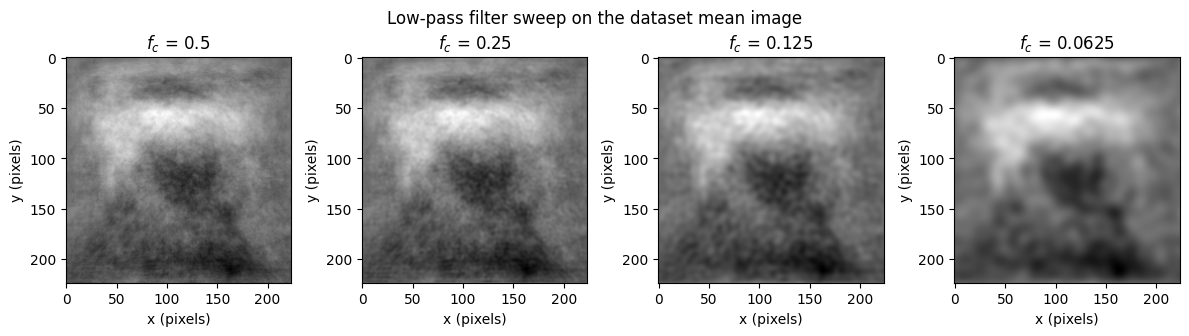

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(cutoffs), figsize=(3 * len(cutoffs), 3.2))
for ax, fc in zip(axes, cutoffs):
    lp = low_pass(gray, fc) if fc < 0.5 else gray
    ax.imshow(lp, cmap="gray")
    ax.set_title(f"$f_c$ = {fc}")
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
plt.suptitle("Low-pass filter sweep on the dataset mean image")
plt.tight_layout()
plt.show()